In [32]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, END
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode

load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

search_tool = TavilySearch(max_results=2)
tools = [search_tool]

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools=tools)

def model(state: AgentState):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])], 
    }

def tools_router(state: AgentState):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    

tool_node = ToolNode(tools=tools)

graph = StateGraph(AgentState)

graph.add_node("model", model)
graph.add_node("tool_node", tool_node)
graph.set_entry_point("model")

graph.add_conditional_edges("model", tools_router)
graph.add_edge("tool_node", "model")

app = graph.compile()

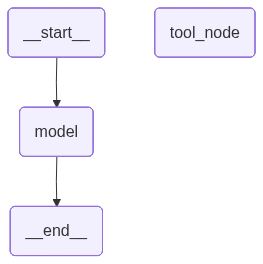

In [33]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [34]:
input = {
    "messages": ["What's the current weather in Bangalore?"]
}

events = app.stream(input=input, stream_mode="values")

for event in events: 
    print(event["messages"])

[HumanMessage(content="What's the current weather in Bangalore?", additional_kwargs={}, response_metadata={}, id='50f6cc58-0233-4312-97f5-aa3e58691c2e')]
[HumanMessage(content="What's the current weather in Bangalore?", additional_kwargs={}, response_metadata={}, id='50f6cc58-0233-4312-97f5-aa3e58691c2e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1194, 'total_tokens': 1217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DZCu060jY6fipcB0cIGusDahFP43s', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dce59-34ff-7150-89c1-978a65d3274c-0', tool_calls=[{'name': 'tavily_search', 'arg

In [8]:
input = {
    "messages": ["What's the current weather in Bangalore?"]
}

events = app.stream(input=input, stream_mode="updates")

for event in events: 
    print(event)

{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1194, 'total_tokens': 1217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DZCDHjwjQGKRA7RCWZzbUTYIr27pQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dce30-ca57-7f81-9b4a-724a6f74fb0c-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current weather in Bangalore', 'topic': 'news'}, 'id': 'call_QdiXYaDFecqXQfrhDPpmMmvd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 23, 'total_tokens': 1217, 'input_token_details': {'audio': 0, 'cache_read': 0}, 

In [ ]:

input = {
    "messages": ["Hi, how are you?"]
}

events = app.astream_events(input=input)

async for event in events: 
    print(event)

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [27]:
graph = app
for chunk in graph.stream(
    {"messages": "What's the Pakistan?"},
    stream_mode=["updates", "custom"],
    version="v2",
):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node {node_name} updated: {state}")
    elif chunk["type"] == "custom":
        print(f"Status: {chunk['data']['status']}")